# Creating a LSTM Forecast model
[📥 Download Notebook](https://github.com/Mosqlimate-project/mosqlimate-client/blob/main/docs/tutorials/lstm_model.ipynb)
 
In this notebook we will show how to create a LSTM forecast model using the `mosqlient` package.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

To download epidemiological data, provide your Mosqlimate API key:

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("API_KEY")

Import the required packages

In [3]:
import torch
import pandas as pd
from datetime import date
import mosqlient as mosq 
import matplotlib.pyplot as plt 
from mosqlient.forecast import ForecastLSTM
from mosqlient.forecast.viz import plot_training_model_loss, plot_model_comparison, plot_single_forecast

/home/eduardocorrea/Documentos/mosqlimate-client/mosqlient/forecast/lstm.py:708: SyntaxWarning: invalid escape sequence '\s'
  """


### Load the dataset

Retrieve historical dengue data from Infodengue.

In [4]:
df = mosq.get_infodengue(
    api_key=api_key,
    disease="dengue",
    uf="SC",
    geocode=4209102, 
    start_date= '2020-01-01', 
    end_date = '2026-07-09'
)

df.head()

100%|██████████| 1/1 [00:00<00:00,  1.41requests/s]


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,municipio_geocodigo,p_rt1,p_inc100k,Localidade_id,...,nivel_inc,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf
0,2020-01-05,202002,4.0,4,4,4,4209102,0.936549,0.669279,0,...,0,83.459870,67.167763,26.904763,31.142857,2,None,None,None,None
1,2020-01-12,202003,4.0,4,4,4,4209102,0.806532,0.669279,0,...,0,76.313103,57.508696,25.229741,28.714286,0,None,None,None,None
2,2020-01-19,202004,5.0,5,5,5,4209102,0.730510,0.836599,0,...,0,80.768472,66.393386,23.968254,27.142857,3,None,None,None,None
3,2020-01-26,202005,5.0,5,5,5,4209102,0.615577,0.836599,0,...,0,82.987376,66.186968,26.634503,30.571429,4,None,None,None,None
4,2020-02-02,202006,17.0,17,17,17,4209102,0.995212,2.844436,0,...,0,91.164054,86.112502,24.359410,25.571429,12,None,None,None,None


The model expects a target variable together with any predictor variables.

In this example:

* `casos` is the target variable.
* `tempmin`, `umidmin`, and `Rt` are explanatory variables.

In [5]:
columns = [
    "data_iniSE",
    "casos",
    "tempmin",
    "umidmin",
    "Rt",
]

### Define the model hyperparameters

These parameters control the neural network architecture and forecasting horizon.


| Parameter    | Description                                              |
| ------------ | -------------------------------------------------------- |
| `look_back`  | Number of previous time steps used as input.             |
| `predict_n`  | Number of future time steps predicted at each iteration. |
| `hidden`     | Number of hidden units in each LSTM layer.               |
| `features`   | Number of input features (excluding the date column).    |
| `dropout`    | Dropout probability used for regularization.             |
| `num_layers` | Number of stacked LSTM layers.                           |



In [6]:
look_back = 4
predict_n = 4

hidden = 16
features = 4
dropout = 0.2
num_layers = 3

criterion = torch.nn.MSELoss()

### Create the forecasting model

Instantiate the ForecastLSTM class.

In [7]:
target_col = 'casos'
FOR_Model = ForecastLSTM(
    df_data=df,
    columns=columns,
    date_col="data_iniSE",
    target_col=target_col,
    hidden=hidden,
    features=features,
    predict_n=predict_n,
    look_back=look_back,
    dropout=dropout,
    num_layers=num_layers,
)

### Train the model

Define the preprocessing options and training period.

The training method automatically performs:

data preprocessing;
optional log transformation (use_log = True);
feature normalization: 
- "max": Divides data by the column-wise maximum (x / max).
- "robust": Subtracts the median and divides by the IQR ((x - median) / IQR).

creation of training and validation datasets;
neural network training with early stopping.

In [8]:
use_log = True
method = "robust"

ini_train_date = "2020-01-01"
end_train_date = "2024-12-31"
end_date = "2025-12-31"

model, hist = FOR_Model.train(
    ini_train_date=ini_train_date,
    end_train_date=end_train_date,
    end_date=end_date,
    use_log=use_log,
    method=method,
    batch_size=2,
    epochs=100,
    patience=30,
    criterion=criterion,
    lr=0.001,
    device="cuda",
)

Epoch 1/100 | Train: 0.4594 | Val: 0.3966
Epoch 2/100 | Train: 0.2965 | Val: 0.1006
Epoch 3/100 | Train: 0.1437 | Val: 0.0581
Epoch 4/100 | Train: 0.1106 | Val: 0.0534
Epoch 5/100 | Train: 0.0887 | Val: 0.0474
Epoch 6/100 | Train: 0.0859 | Val: 0.0442
Epoch 7/100 | Train: 0.0812 | Val: 0.0416
Epoch 8/100 | Train: 0.0665 | Val: 0.0443
Epoch 9/100 | Train: 0.0655 | Val: 0.0397
Epoch 10/100 | Train: 0.0647 | Val: 0.0369
Epoch 11/100 | Train: 0.0577 | Val: 0.0406
Epoch 12/100 | Train: 0.0667 | Val: 0.0452
Epoch 13/100 | Train: 0.0625 | Val: 0.0409
Epoch 14/100 | Train: 0.0620 | Val: 0.0384
Epoch 15/100 | Train: 0.0555 | Val: 0.0336
Epoch 16/100 | Train: 0.0546 | Val: 0.0367
Epoch 17/100 | Train: 0.0500 | Val: 0.0374
Epoch 18/100 | Train: 0.0501 | Val: 0.0312
Epoch 19/100 | Train: 0.0591 | Val: 0.0356
Epoch 20/100 | Train: 0.0541 | Val: 0.0365
Epoch 21/100 | Train: 0.0531 | Val: 0.0346
Epoch 22/100 | Train: 0.0479 | Val: 0.0295
Epoch 23/100 | Train: 0.0485 | Val: 0.0301
Epoch 24/100 | Train

Plot the training and validation losses.

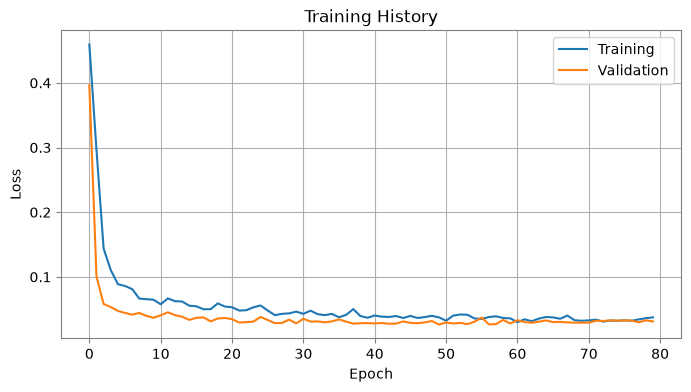

In [9]:
_, ax = plot_training_model_loss(hist)

### In sample performance: 

Generate predictions for the training period.

The returned dataframe contains:

- last observed date used to make the forecast; 
- forecast date;
- prediction horizon;
- observed values;
- predictive distribution statistics.


In [10]:
df_preds_train = FOR_Model.predict_in_sample()

df_preds_train.head()

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon,casos
0,2020-01-26,2020-02-02,22.046377,23.149942,27.524841,32.190479,40.991364,55.807373,69.714760,71.562531,74.852814,1,17
1,2020-01-26,2020-02-09,28.206383,30.298956,35.962563,40.008705,51.656029,66.730888,79.859291,84.901184,87.926659,2,56
2,2020-01-26,2020-02-16,30.957838,37.180859,38.634640,45.513084,58.136101,78.146439,92.847107,96.419861,102.683197,3,80
3,2020-01-26,2020-02-23,36.203526,41.476952,44.700562,55.474125,70.098206,93.896103,109.940704,118.502113,124.985802,4,81
4,2020-02-02,2020-02-09,31.433075,34.225338,39.727295,44.667858,56.510918,76.380333,90.066795,99.957184,112.187508,1,56


Visualize the one-step-ahead forecasts.

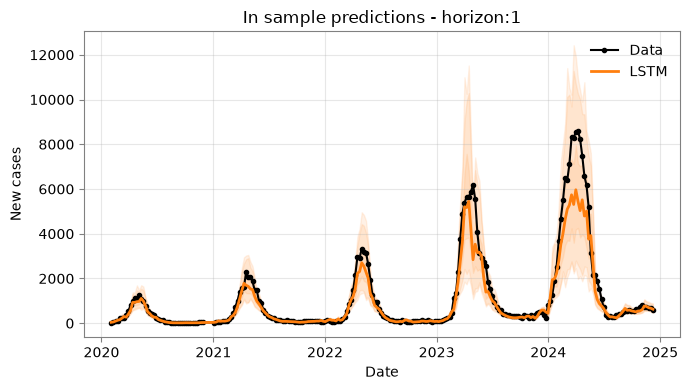

In [11]:
horizon =1 

_,ax = plot_model_comparison(
    df_preds = df_preds_train.loc[df_preds_train.horizon == horizon],
    date_col = "date",
    target_col = "casos",
    label = "LSTM",
    conf_levels=[0.5, 0.90, 0.95],
    title = f"In sample predictions - horizon:{horizon}",
    xlabel= "Date",
    ylabel = "New cases")

### Evaluate out-of-sample performance

Generate predictions for the test period.

In [12]:
df_preds_test = FOR_Model.predict_out_of_sample()

df_preds_test.head()

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon,casos
0,2024-12-29,2025-01-05,412.147614,420.898590,439.702362,471.580200,515.048218,597.170288,641.667725,655.414978,732.232910,1,589
1,2024-12-29,2025-01-12,425.356445,430.313263,448.986145,478.890442,520.807861,582.237793,632.433289,655.546326,708.489990,2,548
2,2024-12-29,2025-01-19,415.056976,421.775574,444.541992,475.124054,516.496643,566.923889,618.200439,652.646179,667.123718,3,552
3,2024-12-29,2025-01-26,406.121185,418.643036,443.790833,469.536621,505.371704,554.574219,597.177612,637.858765,649.927490,4,536
4,2025-01-05,2025-01-12,499.162842,545.861572,573.021667,620.919922,689.860840,791.775452,882.344360,927.286804,949.606079,1,548


Visualize the one-step-ahead forecasts.

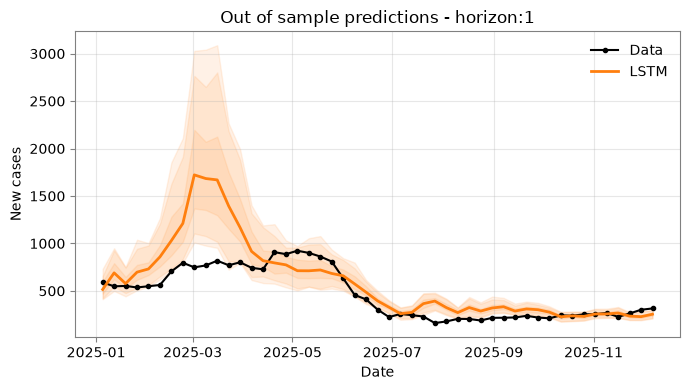

In [13]:
horizon =1 

_,ax = plot_model_comparison(
    df_preds = df_preds_test.loc[df_preds_test.horizon == horizon],
    date_col = "date",
    target_col = "casos",
    label = "LSTM",
    conf_levels=[0.5, 0.90, 0.95],
    title = f"Out of sample predictions - horizon:{horizon}",
    xlabel= "Date",
    ylabel = "New cases")

### Generate future forecasts

After training, the model can generate forecasts beyond the available observations. The forecasting process starts from the last date specified in the `end_date` parameter used during training. This date must fall within the time range of the `df_data` provided when initializing the `ForecastLSTM` class. The method automatically reuses the preprocessing parameters (such as normalization and optional log transformation) learned during training, ensuring that new input data are scaled consistently before generating forecasts.

In [14]:
df_forecast = FOR_Model.forecast(
    end_date="2025-01-05",
    n_samples=100,
)

df_forecast.head()

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon
0,2025-01-05,2025-01-12,524.156982,530.590393,546.429932,611.192566,679.848145,790.562073,902.108337,938.990662,1004.126221,1
1,2025-01-05,2025-01-19,538.761963,550.116272,568.071289,626.677124,700.386230,799.784607,899.686401,969.811951,995.652649,2
2,2025-01-05,2025-01-26,547.895508,562.488708,584.095459,635.821777,705.618652,800.665466,890.670776,953.849365,996.846252,3
3,2025-01-05,2025-02-02,548.471680,561.417664,580.822876,627.264771,708.008606,794.018005,887.169678,938.509583,994.454590,4


Plot the forecasts: 

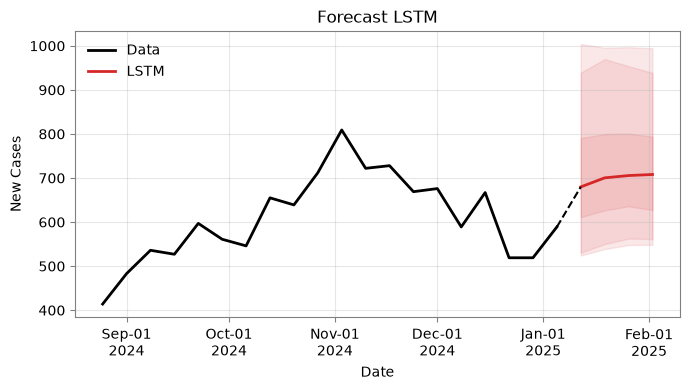

In [15]:
_,ax = plot_single_forecast(
    df_for = df_forecast,
    df_train=FOR_Model.df_model.reset_index().rename(columns = {'data_iniSE': 'date'}),
    last_obs = 20,
    target_col=target_col,
    date_col="date",
    conf_levels=[0.5, 0.90, 0.95],
    title="Forecast LSTM",
    label="LSTM",
    xlabel="Date",
    ylabel="New Cases",
    figsize=(7, 4))